# ⭐ Day 42: Time Series EDA
## 📅 Store Sales Dataset – Mastering Temporal Data Exploration
### Day 42 of 369-day Python & AI Learning Path

---


## 🕒 Welcome to Day 42!

Congratulations on reaching Day 42 of your Python & AI journey! Today we venture into one of the most practically important domains in data science: **time series analysis**. While image data (like CIFAR-10) explores spatial patterns, time series data unlocks the temporal dimension—how values change and evolve over time.

Time series data is everywhere in the real world: daily sales transactions, hourly sensor readings, stock prices ticking every minute, website traffic logs, and energy consumption meters. The ability to properly explore and understand temporal patterns is a cornerstone skill for demand forecasting, anomaly detection, financial modeling, and operational planning. Unlike static datasets, time series introduces unique challenges: trends that drift over years, seasonal patterns that repeat weekly or annually, autocorrelation where today's values depend on yesterday's, and irregular shocks that appear as outliers.

In this notebook, we'll analyze a realistic **Store Sales dataset**, mimicking the kind of data retailers generate every day. We'll learn to decompose sales into trend, seasonality, and residual components; detect weekly and monthly patterns; identify anomalies; and engineer lag features that capture temporal dependencies. These skills directly translate to building forecasting models like ARIMA, Prophet, or deep learning approaches (LSTMs, Transformers).

By the end of this session, you'll understand how to:
- 📊 Handle datetime data and time-based indexing in pandas
- 📈 Visualize temporal trends at multiple granularities (daily, weekly, monthly)
- 🔄 Decompose time series into interpretable components
- 🎯 Detect seasonality and cyclical patterns
- ⚠️ Identify outliers and anomalies in temporal contexts
- 🔗 Analyze autocorrelation and build lag features

Let's unlock the secrets hidden in time! ⏳


## 📋 Table of Contents

1. [Introduction to Time Series Data](#1-introduction-to-time-series-data-and-store-sales-problem)
2. [Loading the Dataset](#2-loading-the-dataset-and-converting-dates)
3. [Basic Time Series Inspection](#3-basic-time-series-inspection)
4. [Visualizing Sales Over Time](#4-visualizing-sales-over-time)
5. [Seasonality Analysis](#5-seasonality-analysis)
6. [Trend Detection and Decomposition](#6-trend-detection-and-decomposition)
7. [Sales Distribution and Outlier Analysis](#7-sales-distribution-and-outlier-analysis)
8. [Analyzing Sales by Store and Category](#8-analyzing-sales-by-store--category--promotion)
9. [Lag Features and Autocorrelation](#9-lag-features-and-autocorrelation)
10. [Key Insights for Forecasting](#10-key-insights-for-time-series-forecasting-models)
11. [EDA Summary and Recommendations](#11-eda-summary-and-recommendations)
12. [🛠️ Hands-On Exercises](#-hands-on-exercises)
13. [Solutions & Key Insights](#-solutions--key-insights-review-after-attempting)


## 1. Introduction to Time Series Data and Store Sales Problem

**Time Series Data** consists of observations collected sequentially over time. Unlike cross-sectional data, the order matters—temporal dependencies are often the most important feature!

### Key Characteristics:
- **Temporal dependence**: Current values correlate with past values
- **Trend**: Long-term increase or decrease in the series
- **Seasonality**: Regular, periodic fluctuations (daily, weekly, yearly)
- **Cyclical patterns**: Longer-term business cycles (not fixed periods)
- **Noise/Residual**: Random, unexplained variation

### Our Store Sales Dataset:
We'll work with a synthetic but realistic retail dataset containing:
- **Date**: Daily timestamps over 2+ years
- **Store ID**: Multiple store locations
- **Sales**: Daily revenue figures
- **Customers**: Daily customer count
- **Promotions**: Binary indicator for promotional periods
- **DayOfWeek**: 0=Monday through 6=Sunday
- **IsHoliday**: Indicator for public holidays

### Business Questions We'll Answer:
1. 📈 What is the overall sales trend? Growing, declining, or stable?
2. 🗓️ What seasonal patterns exist? Weekend spikes? Holiday effects?
3. 🏬 Do different stores show different patterns?
4. 🎯 How effective are promotions?
5. ⚠️ Are there anomalies or data quality issues?
6. 🔮 What features would help forecast future sales?


In [17]:
# 📦 Import essential libraries for Time Series EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Time series specific imports
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

# 🎨 Set up beautiful visualization defaults
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries imported successfully!")
print("🎯 Ready to explore Time Series data")
print("📦 Key packages: pandas (datetime), statsmodels (decomposition, ACF)")


✅ Libraries imported successfully!
🎯 Ready to explore Time Series data
📦 Key packages: pandas (datetime), statsmodels (decomposition, ACF)


## 2. Loading the Dataset and Converting Dates

We'll create a realistic synthetic Store Sales dataset. In practice, you'd load this from CSV, Excel, or a database.


In [18]:
# 🏗️ Generate realistic synthetic Store Sales dataset
def generate_store_sales_data(n_stores=5, start_date='2021-01-01', periods=730):
    """
    Generate synthetic store sales data with realistic patterns:
    - Trend component
    - Weekly seasonality (weekends higher)
    - Yearly seasonality (holiday seasons)
    - Promotional spikes
    - Random noise
    """
    # Create date range
    dates = pd.date_range(start=start_date, periods=periods, freq='D')
    
    data = []
    for store_id in range(1, n_stores + 1):
        for date in dates:
            # Base sales with store-specific multiplier
            base_sales = 1000 + (store_id * 200)
            
            # Trend (slight growth over time)
            day_number = (date - pd.to_datetime(start_date)).days
            trend = 1 + (day_number / periods) * 0.2  # 20% growth over period
            
            # Weekly seasonality (weekends higher: Fri, Sat, Sun)
            day_of_week = date.dayofweek  # 0=Monday, 6=Sunday
            if day_of_week >= 4:  # Friday, Saturday, Sunday
                weekly_factor = 1.3 + np.random.normal(0, 0.1)
            elif day_of_week == 0:  # Monday (lower)
                weekly_factor = 0.8 + np.random.normal(0, 0.05)
            else:
                weekly_factor = 1.0 + np.random.normal(0, 0.05)
            
            # Yearly seasonality (November-December peak)
            month = date.month
            if month in [11, 12]:  # Holiday season
                yearly_factor = 1.4 + np.random.normal(0, 0.1)
            elif month in [6, 7, 8]:  # Summer
                yearly_factor = 1.1 + np.random.normal(0, 0.05)
            else:
                yearly_factor = 1.0
            
            # Promotions (random 10% of days, 30% boost)
            is_promo = np.random.random() < 0.1
            promo_factor = 1.3 if is_promo else 1.0
            
            # Holidays (occasional, 50% boost)
            is_holiday = np.random.random() < 0.03
            holiday_factor = 1.5 if is_holiday else 1.0
            
            # Random noise
            noise = np.random.normal(1, 0.1)
            
            # Calculate final sales
            sales = base_sales * trend * weekly_factor * yearly_factor * promo_factor * holiday_factor * noise
            sales = max(0, round(sales, 2))  # Ensure non-negative
            
            # Customer count (correlated with sales)
            customers = int(sales / 15 + np.random.normal(0, 10))
            customers = max(0, customers)
            
            data.append({
                'Date': date,
                'Store': store_id,
                'Sales': sales,
                'Customers': customers,
                'Promo': int(is_promo),
                'IsHoliday': int(is_holiday),
                'DayOfWeek': day_of_week,
                'Month': month,
                'Year': date.year
            })
    
    return pd.DataFrame(data)

# Generate the dataset
print("⏳ Generating synthetic Store Sales dataset...")
df = generate_store_sales_data(n_stores=5, periods=730)  # 2 years of data

print("✅ Dataset generated successfully!")
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"   Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"   Total days: {(df['Date'].max() - df['Date'].min()).days + 1}")
print(f"   Number of stores: {df['Store'].nunique()}")


⏳ Generating synthetic Store Sales dataset...
✅ Dataset generated successfully!

📊 Dataset Shape: (3650, 9)
   Date range: 2021-01-01 00:00:00 to 2022-12-31 00:00:00
   Total days: 730
   Number of stores: 5


In [19]:
# 🔍 Quick inspection of the dataset
print("=" * 70)
print("📋 FIRST 5 ROWS")
print("=" * 70)
print(df.head())

print("\n" + "=" * 70)
print("📋 DATASET INFO")
print("=" * 70)
print(df.info())

print("\n" + "=" * 70)
print("📋 NUMERIC SUMMARY")
print("=" * 70)
print(df.describe())

print("\n" + "=" * 70)
print("📋 DATE COLUMN TYPE CHECK")
print("=" * 70)
print(f"Date column dtype: {df['Date'].dtype}")
print(f"Sample date values: {df['Date'].head(3).tolist()}")


📋 FIRST 5 ROWS
        Date  Store    Sales  Customers  Promo  IsHoliday  DayOfWeek  Month  \
0 2021-01-01      1  1597.21        104      0          0          4      1   
1 2021-01-02      1  2306.60        161      1          0          5      1   
2 2021-01-03      1  1586.11        108      0          0          6      1   
3 2021-01-04      1   760.22         53      0          0          0      1   
4 2021-01-05      1   984.81         66      0          0          1      1   

   Year  
0  2021  
1  2021  
2  2021  
3  2021  
4  2021  

📋 DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3650 non-null   datetime64[us]
 1   Store      3650 non-null   int64         
 2   Sales      3650 non-null   float64       
 3   Customers  3650 non-null   int64         
 4   Promo      3650 non-null   int64         
 5   IsHol

## 3. Basic Time Series Inspection

Before analysis, we must understand the temporal structure: date range, frequency, gaps, and data quality.


In [20]:
# 📅 Basic time series inspection
print("=" * 70)
print("🕒 TEMPORAL STRUCTURE ANALYSIS")
print("=" * 70)

# Set Date as index for time series operations
df_ts = df.set_index('Date').sort_index()

print(f"\n📆 Date Range:")
print(f"   Start: {df['Date'].min()}")
print(f"   End:   {df['Date'].max()}")
print(f"   Duration: {(df['Date'].max() - df['Date'].min()).days} days ({(df['Date'].max() - df['Date'].min()).days / 365.25:.1f} years)")

print(f"\n📊 Frequency Analysis:")
date_diffs = df['Date'].diff().dropna().unique()
print(f"   Unique intervals: {date_diffs}")
print(f"   Expected frequency: Daily (D)")

# Check for missing dates
print(f"\n🔍 Missing Date Check:")
full_date_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
missing_dates = set(full_date_range) - set(df['Date'].unique())
print(f"   Total expected dates: {len(full_date_range)}")
print(f"   Actual unique dates: {df['Date'].nunique()}")
print(f"   Missing dates: {len(missing_dates)}")
if missing_dates:
    print(f"   Example missing: {list(missing_dates)[:5]}")
else:
    print(f"   ✅ No missing dates detected!")

print(f"\n🏪 Store Coverage:")
store_counts = df.groupby('Store')['Date'].agg(['min', 'max', 'count'])
print(store_counts)

print(f"\n📈 Data Quality Flags:")
print(f"   Duplicate rows: {df.duplicated().sum()}")
print(f"   Missing values: {df.isnull().sum().sum()}")
print(f"   Negative sales: {(df['Sales'] < 0).sum()}")
print(f"   Zero sales: {(df['Sales'] == 0).sum()}")


🕒 TEMPORAL STRUCTURE ANALYSIS

📆 Date Range:
   Start: 2021-01-01 00:00:00
   End:   2022-12-31 00:00:00
   Duration: 729 days (2.0 years)

📊 Frequency Analysis:
   Unique intervals: <TimedeltaArray>
['1 days', '-729 days']
Length: 2, dtype: timedelta64[us]
   Expected frequency: Daily (D)

🔍 Missing Date Check:
   Total expected dates: 730
   Actual unique dates: 730
   Missing dates: 0
   ✅ No missing dates detected!

🏪 Store Coverage:
             min        max  count
Store                             
1     2021-01-01 2022-12-31    730
2     2021-01-01 2022-12-31    730
3     2021-01-01 2022-12-31    730
4     2021-01-01 2022-12-31    730
5     2021-01-01 2022-12-31    730

📈 Data Quality Flags:
   Duplicate rows: 0
   Missing values: 0
   Negative sales: 0
   Zero sales: 0


## 4. Visualizing Sales Over Time

Time series visualization is the foundation of EDA. We'll explore different temporal granularities.


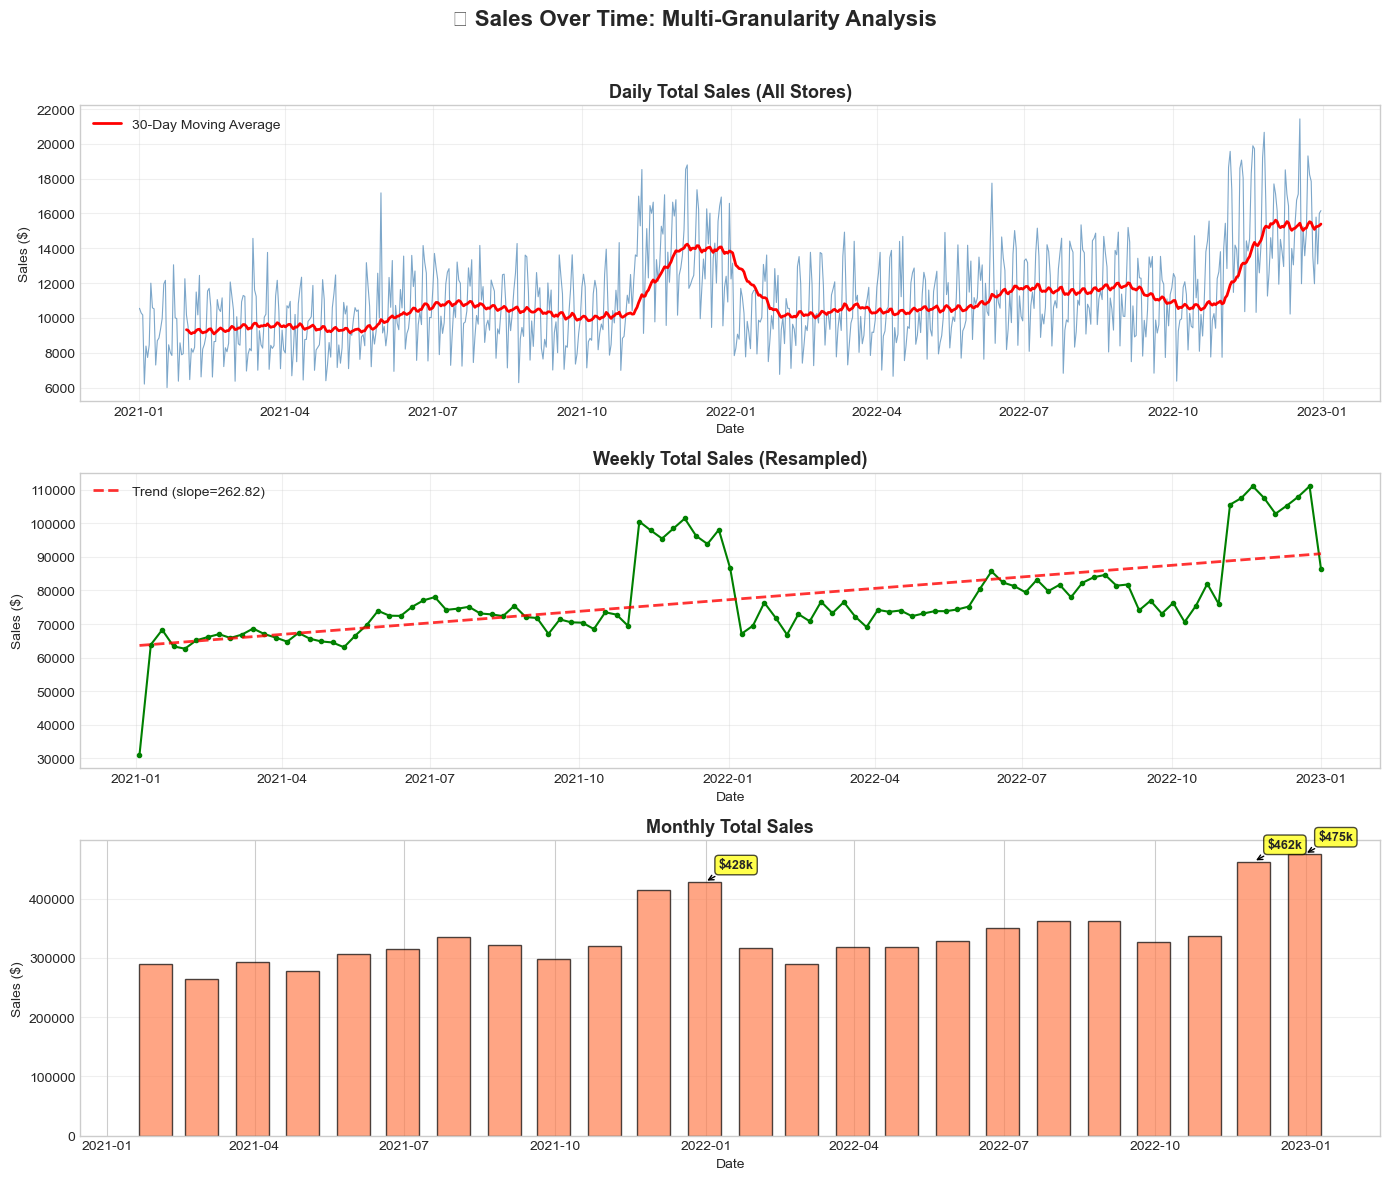


💡 KEY INSIGHT: Multi-Granularity Visualization
✅ Daily view shows noise and short-term fluctuations
✅ Weekly view reveals clearer patterns and trends
✅ Monthly view highlights seasonal peaks and long-term trends
📊 Trend Analysis: Sales show upward trend of $262.82 per week


In [21]:
# 📈 Create comprehensive time series visualizations
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('📈 Sales Over Time: Multi-Granularity Analysis', fontsize=16, fontweight='bold')

# Aggregate sales by date (all stores combined)
daily_sales = df.groupby('Date')['Sales'].sum()

# Plot 1: Daily Sales (raw)
axes[0].plot(daily_sales.index, daily_sales.values, linewidth=0.8, alpha=0.7, color='steelblue')
axes[0].set_title('Daily Total Sales (All Stores)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(True, alpha=0.3)

# Add 30-day rolling mean
rolling_mean_30 = daily_sales.rolling(window=30).mean()
axes[0].plot(rolling_mean_30.index, rolling_mean_30.values, 
             linewidth=2, color='red', label='30-Day Moving Average')
axes[0].legend()

# Plot 2: Weekly Sales (resampled)
weekly_sales = daily_sales.resample('W').sum()
axes[1].plot(weekly_sales.index, weekly_sales.values, linewidth=1.5, 
             marker='o', markersize=3, color='green')
axes[1].set_title('Weekly Total Sales (Resampled)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales ($)')
axes[1].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(range(len(weekly_sales)), weekly_sales.values, 1)
p = np.poly1d(z)
axes[1].plot(weekly_sales.index, p(range(len(weekly_sales))), 
             "r--", alpha=0.8, linewidth=2, label=f'Trend (slope={z[0]:.2f})')
axes[1].legend()

# Plot 3: Monthly Sales
monthly_sales = daily_sales.resample('ME').sum()
axes[2].bar(monthly_sales.index, monthly_sales.values, 
            width=20, alpha=0.7, color='coral', edgecolor='black')
axes[2].set_title('Monthly Total Sales', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Sales ($)')
axes[2].grid(True, alpha=0.3, axis='y')

# Highlight peak months
peak_months = monthly_sales.nlargest(3)
for date, value in peak_months.items():
    axes[2].annotate(f'${value/1000:.0f}k', 
                     xy=(date, value), 
                     xytext=(10, 10), 
                     textcoords='offset points',
                     fontsize=9, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n" + "=" * 70)
print("💡 KEY INSIGHT: Multi-Granularity Visualization")
print("=" * 70)
print("✅ Daily view shows noise and short-term fluctuations")
print("✅ Weekly view reveals clearer patterns and trends")
print("✅ Monthly view highlights seasonal peaks and long-term trends")
print(f"📊 Trend Analysis: Sales show {'upward' if z[0] > 0 else 'downward'} trend of ${z[0]:.2f} per week")


## 5. Seasonality Analysis

Seasonality refers to periodic patterns. Let's analyze weekly, monthly, and yearly cycles.


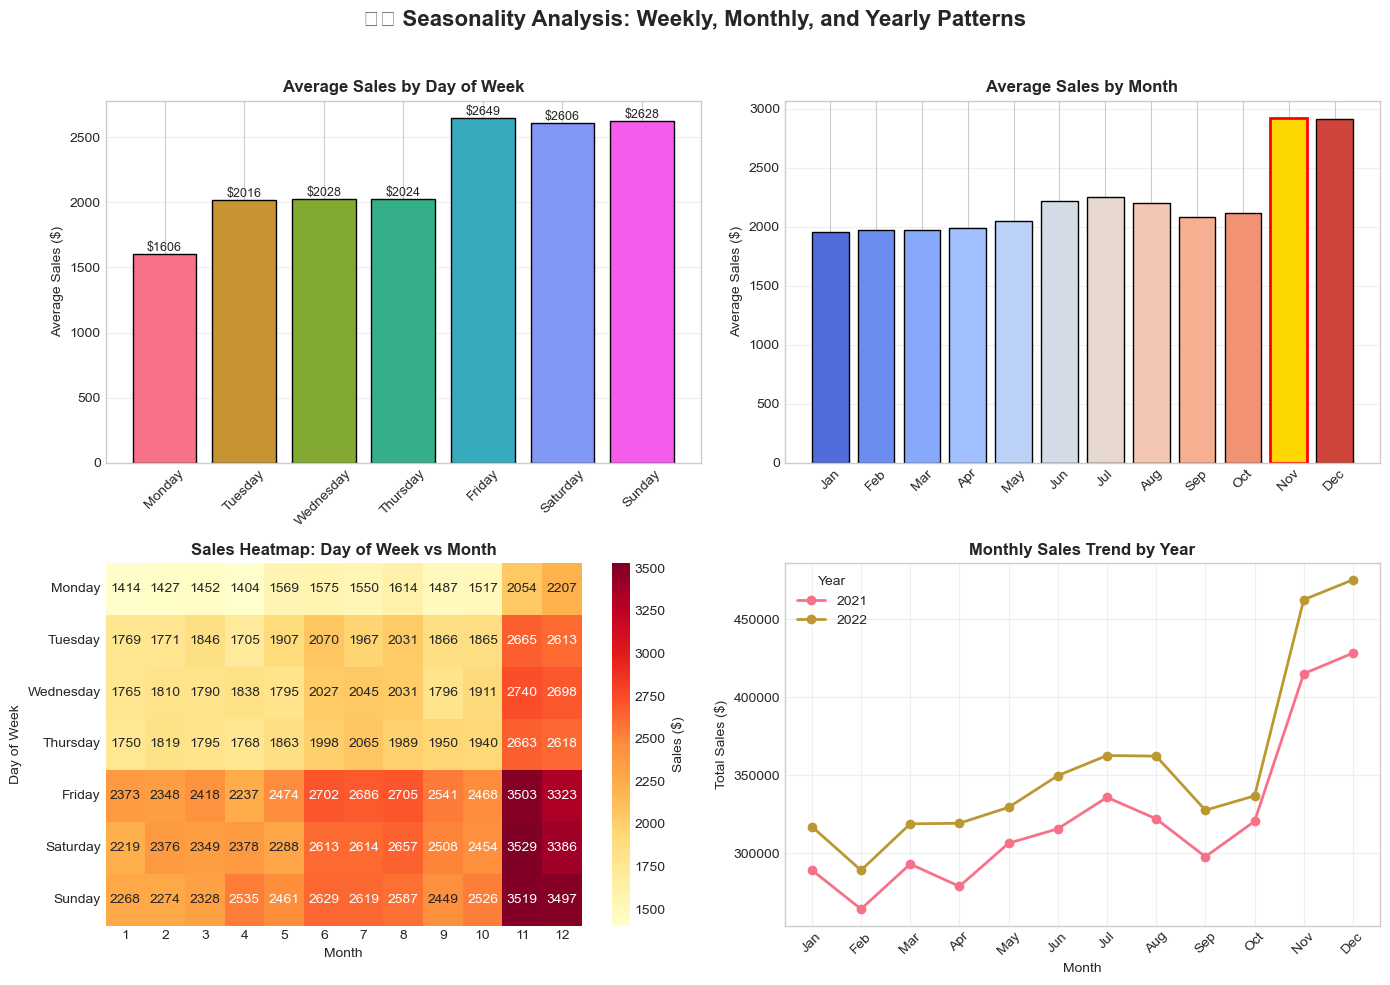


💡 KEY INSIGHT: Seasonality Patterns Detected
📅 Weekly Pattern: Fridays are peak (2649), Mondays are lowest (1606)
📆 Monthly Pattern: November is peak season (2925)
📊 Weekend vs Weekday: 36.4% higher on weekends


In [22]:
# 🗓️ Comprehensive seasonality analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🗓️ Seasonality Analysis: Weekly, Monthly, and Yearly Patterns', 
             fontsize=16, fontweight='bold')

# Prepare data with time features
df['DayName'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

# 1. Day of Week Pattern
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df.groupby('DayName')['Sales'].mean().reindex(dow_order)

bars1 = axes[0, 0].bar(dow_sales.index, dow_sales.values, 
                       color=sns.color_palette("husl", 7), edgecolor='black')
axes[0, 0].set_title('Average Sales by Day of Week', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Average Sales ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:.0f}', ha='center', va='bottom', fontsize=9)

# 2. Monthly Pattern
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg = df.groupby('MonthName')['Sales'].mean().reindex(month_order)

bars2 = axes[0, 1].bar(range(12), monthly_avg.values, 
                       color=sns.color_palette("coolwarm", 12), edgecolor='black')
axes[0, 1].set_title('Average Sales by Month', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Sales ($)')
axes[0, 1].set_xticks(range(12))
axes[0, 1].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Highlight peak months
peak_idx = monthly_avg.values.argmax()
bars2[peak_idx].set_color('gold')
bars2[peak_idx].set_edgecolor('red')
bars2[peak_idx].set_linewidth(2)

# 3. Heatmap: Day of Week vs Month
pivot_table = df.pivot_table(values='Sales', index='DayName', 
                             columns='Month', aggfunc='mean')
pivot_table = pivot_table.reindex(dow_order)

sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', 
            ax=axes[1, 0], cbar_kws={'label': 'Sales ($)'})
axes[1, 0].set_title('Sales Heatmap: Day of Week vs Month', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Day of Week')

# 4. Year-over-Year Comparison (if multiple years)
yearly_monthly = df.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)
yearly_monthly.plot(kind='line', ax=axes[1, 1], marker='o', linewidth=2)
axes[1, 1].set_title('Monthly Sales Trend by Year', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Sales ($)')
axes[1, 1].legend(title='Year')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels([m[:3] for m in month_order], rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n" + "=" * 70)
print("💡 KEY INSIGHT: Seasonality Patterns Detected")
print("=" * 70)
print(f"📅 Weekly Pattern: {dow_sales.idxmax()}s are peak ({dow_sales.max():.0f}), "
      f"{dow_sales.idxmin()}s are lowest ({dow_sales.min():.0f})")
print(f"📆 Monthly Pattern: {monthly_avg.idxmax()} is peak season ({monthly_avg.max():.0f})")
print(f"📊 Weekend vs Weekday: {(dow_sales[['Saturday', 'Sunday']].mean() / dow_sales[['Monday', 'Tuesday', 'Wednesday', 'Thursday']].mean() - 1) * 100:.1f}% higher on weekends")


## 6. Trend Detection and Decomposition

Time series decomposition separates the signal into trend, seasonal, and residual components. This is crucial for understanding underlying patterns.


⏳ Performing seasonal decomposition...


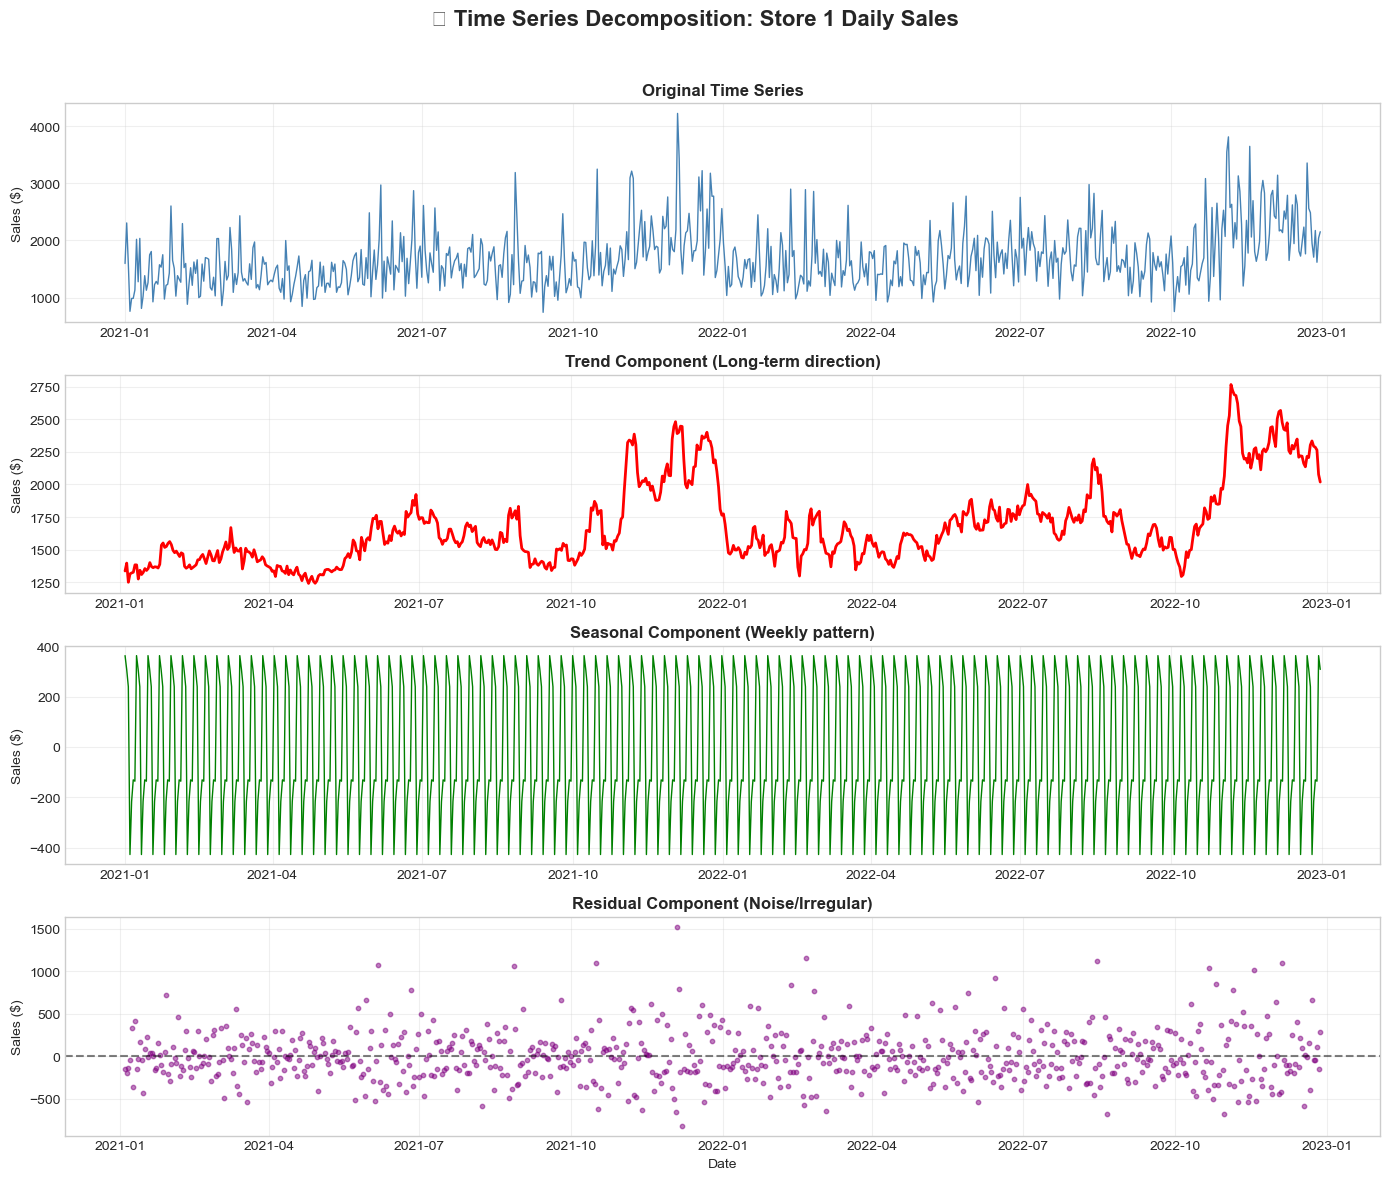


📊 DECOMPOSITION ANALYSIS RESULTS
📈 Trend: Upward slope of $0.77 per day
🔄 Seasonal Strength: 55.04% (seasonal std / total std)
📉 Residual Std: $299.20 (unexplained variation)
✅ Variance Explained: 65.5%


In [23]:
# 🔄 Time Series Decomposition
print("⏳ Performing seasonal decomposition...")

# Prepare daily sales time series (single store for clarity)
store1_daily = df[df['Store'] == 1].set_index('Date')['Sales'].sort_index()

# Decompose (additive model: Sales = Trend + Seasonal + Residual)
decomposition = seasonal_decompose(store1_daily, model='additive', period=7)  # Weekly seasonality

# Create comprehensive decomposition plot
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('🔄 Time Series Decomposition: Store 1 Daily Sales', 
             fontsize=16, fontweight='bold')

# Original
axes[0].plot(store1_daily.index, store1_daily.values, color='steelblue', linewidth=1)
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decomposition.trend.index, decomposition.trend.values, 
             color='red', linewidth=2)
axes[1].set_title('Trend Component (Long-term direction)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sales ($)')
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, 
             color='green', linewidth=1)
axes[2].set_title('Seasonal Component (Weekly pattern)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Sales ($)')
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].scatter(decomposition.resid.index, decomposition.resid.values, 
                alpha=0.5, color='purple', s=10)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[3].set_title('Residual Component (Noise/Irregular)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Sales ($)')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Calculate component statistics
trend_slope = np.polyfit(range(len(decomposition.trend.dropna())), 
                         decomposition.trend.dropna(), 1)[0]
seasonal_strength = np.std(decomposition.seasonal) / np.std(store1_daily)
residual_std = np.std(decomposition.resid.dropna())

print("\n" + "=" * 70)
print("📊 DECOMPOSITION ANALYSIS RESULTS")
print("=" * 70)
print(f"📈 Trend: {'Upward' if trend_slope > 0 else 'Downward'} slope of ${trend_slope:.2f} per day")
print(f"🔄 Seasonal Strength: {seasonal_strength:.2%} (seasonal std / total std)")
print(f"📉 Residual Std: ${residual_std:.2f} (unexplained variation)")
print(f"✅ Variance Explained: {(1 - np.var(decomposition.resid.dropna()) / np.var(store1_daily)) * 100:.1f}%")


## 7. Sales Distribution and Outlier Analysis

Understanding the distribution helps identify anomalies and choose appropriate forecasting models.


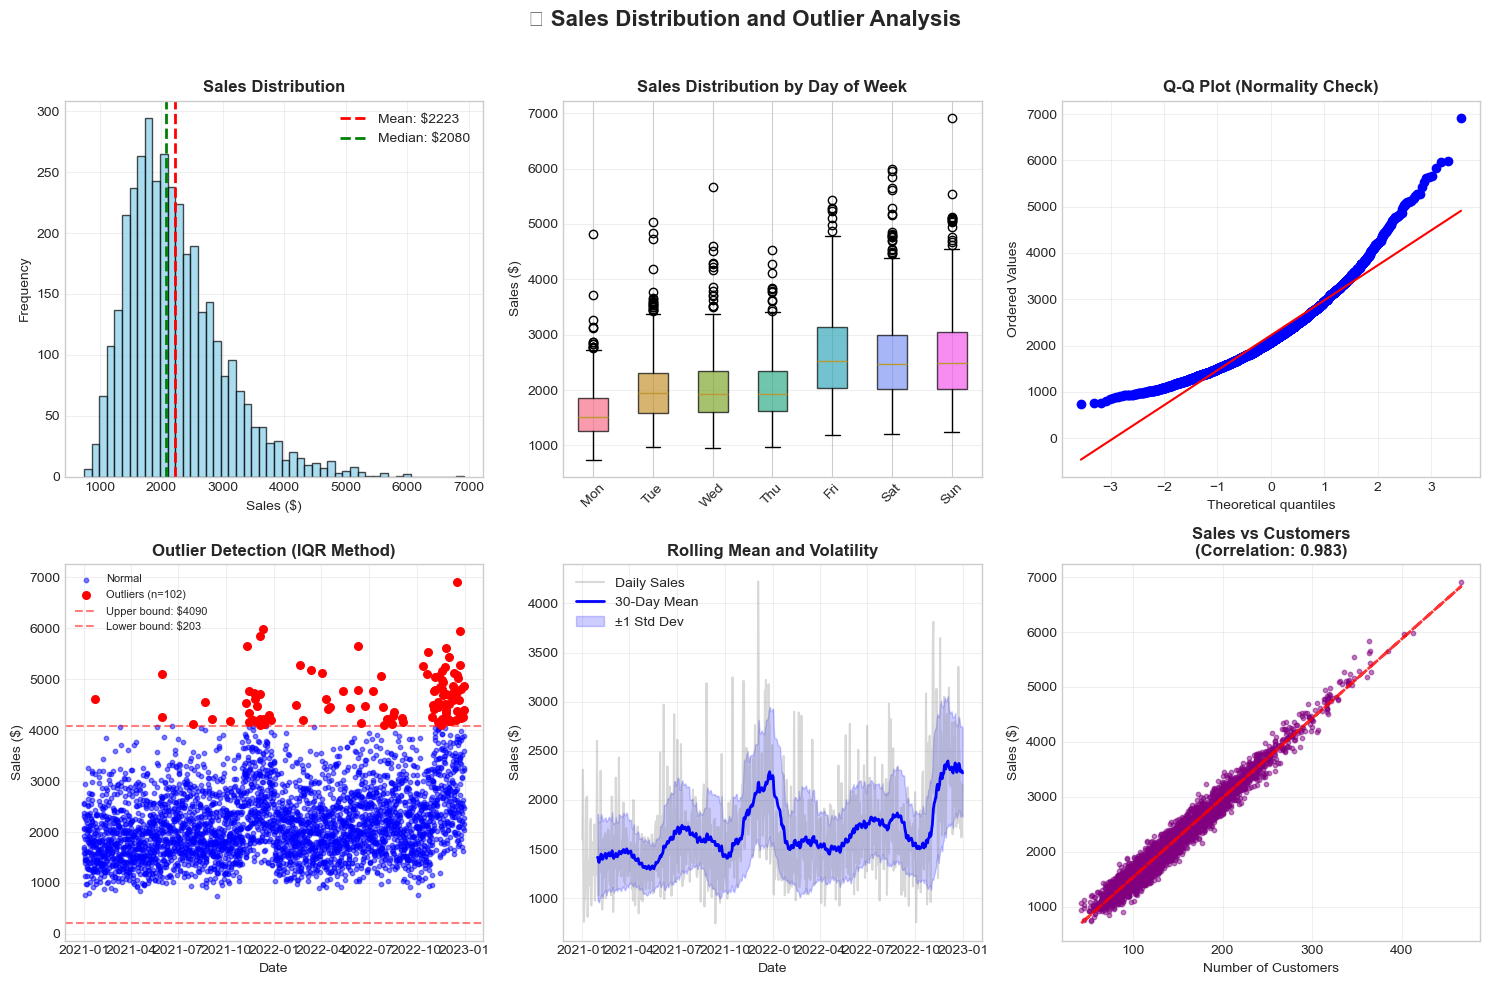


📊 DISTRIBUTION ANALYSIS SUMMARY
📈 Distribution: Right-skewed (skewness: 1.13)
📊 Kurtosis: 1.90 (Light tails)
⚠️  Outliers detected: 102 (2.79% of data)
🔗 Sales-Customer correlation: 0.983 (Strong)


In [24]:
# 📊 Distribution and outlier analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📊 Sales Distribution and Outlier Analysis', fontsize=16, fontweight='bold')

# 1. Histogram of sales
axes[0, 0].hist(df['Sales'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['Sales'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: ${df["Sales"].mean():.0f}')
axes[0, 0].axvline(df['Sales'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: ${df["Sales"].median():.0f}')
axes[0, 0].set_title('Sales Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sales ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot by day of week
dow_data = [df[df['DayName'] == day]['Sales'].values for day in dow_order]
bp = axes[0, 1].boxplot(dow_data, labels=[d[:3] for d in dow_order], patch_artist=True)
colors = sns.color_palette("husl", 7)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_title('Sales Distribution by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Sales ($)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Q-Q plot for normality check
from scipy import stats
stats.probplot(df['Sales'], dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. Outlier detection using IQR method
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

axes[1, 0].scatter(df['Date'], df['Sales'], alpha=0.5, s=10, label='Normal', color='blue')
axes[1, 0].scatter(outliers['Date'], outliers['Sales'], 
                   color='red', s=30, label=f'Outliers (n={len(outliers)})', zorder=5)
axes[1, 0].axhline(y=upper_bound, color='red', linestyle='--', alpha=0.5, label=f'Upper bound: ${upper_bound:.0f}')
axes[1, 0].axhline(y=lower_bound, color='red', linestyle='--', alpha=0.5, label=f'Lower bound: ${lower_bound:.0f}')
axes[1, 0].set_title('Outlier Detection (IQR Method)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Sales ($)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 5. Rolling statistics (volatility)
rolling_mean = store1_daily.rolling(window=30).mean()
rolling_std = store1_daily.rolling(window=30).std()

axes[1, 1].plot(store1_daily.index, store1_daily.values, alpha=0.3, label='Daily Sales', color='gray')
axes[1, 1].plot(rolling_mean.index, rolling_mean.values, label='30-Day Mean', color='blue', linewidth=2)
axes[1, 1].fill_between(rolling_std.index, 
                        rolling_mean - rolling_std, 
                        rolling_mean + rolling_std, 
                        alpha=0.2, color='blue', label='±1 Std Dev')
axes[1, 1].set_title('Rolling Mean and Volatility', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Sales ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Sales vs Customers scatter
axes[1, 2].scatter(df['Customers'], df['Sales'], alpha=0.5, s=10, color='purple')
z = np.polyfit(df['Customers'], df['Sales'], 1)
p = np.poly1d(z)
axes[1, 2].plot(df['Customers'], p(df['Customers']), "r--", alpha=0.8, linewidth=2)
correlation = df['Customers'].corr(df['Sales'])
axes[1, 2].set_title(f'Sales vs Customers\n(Correlation: {correlation:.3f})', 
                     fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Number of Customers')
axes[1, 2].set_ylabel('Sales ($)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n" + "=" * 70)
print("📊 DISTRIBUTION ANALYSIS SUMMARY")
print("=" * 70)
print(f"📈 Distribution: {'Right-skewed' if df['Sales'].skew() > 0 else 'Left-skewed'} "
      f"(skewness: {df['Sales'].skew():.2f})")
print(f"📊 Kurtosis: {df['Sales'].kurtosis():.2f} ({'Heavy tails' if df['Sales'].kurtosis() > 3 else 'Light tails'})")
print(f"⚠️  Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")
print(f"🔗 Sales-Customer correlation: {correlation:.3f} ({'Strong' if abs(correlation) > 0.7 else 'Moderate' if abs(correlation) > 0.4 else 'Weak'})")


## 8. Analyzing Sales by Store / Category / Promotion

Understanding heterogeneity across stores and the impact of promotions is crucial for business strategy.


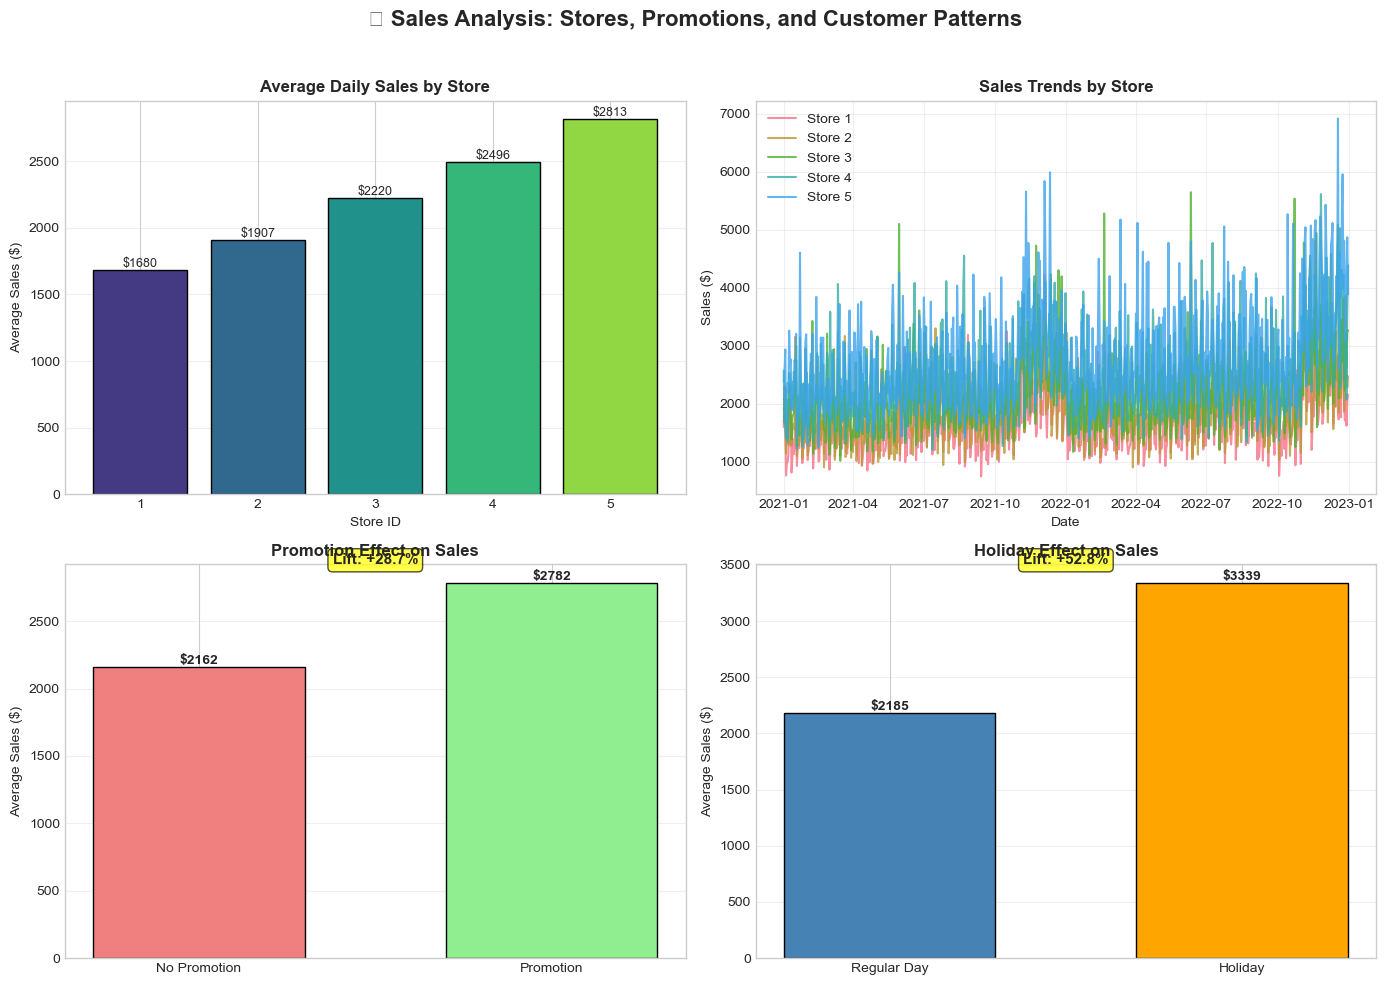


💡 KEY INSIGHTS: Business Drivers
🏪 Store Performance: Store 5 leads ($2813 vs $1680 for Store 1)
🎯 Promotion Impact: 28.7% sales lift during promotions
🎉 Holiday Impact: 52.8% sales lift on holidays
📊 Promotion frequency: 9.8% of days


In [25]:
# 🏬 Multi-dimensional analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🏬 Sales Analysis: Stores, Promotions, and Customer Patterns', 
             fontsize=16, fontweight='bold')

# 1. Sales by Store
store_stats = df.groupby('Store').agg({
    'Sales': ['mean', 'sum', 'std'],
    'Customers': 'mean'
}).round(2)
store_stats.columns = ['Avg_Sales', 'Total_Sales', 'Sales_Std', 'Avg_Customers']

bars = axes[0, 0].bar(store_stats.index, store_stats['Avg_Sales'], 
                      color=sns.color_palette("viridis", 5), edgecolor='black')
axes[0, 0].set_title('Average Daily Sales by Store', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Store ID')
axes[0, 0].set_ylabel('Average Sales ($)')
axes[0, 0].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:.0f}', ha='center', va='bottom', fontsize=9)

# 2. Time series by store
for store in df['Store'].unique():
    store_data = df[df['Store'] == store].groupby('Date')['Sales'].sum()
    axes[0, 1].plot(store_data.index, store_data.values, 
                    label=f'Store {store}', linewidth=1.5, alpha=0.8)
axes[0, 1].set_title('Sales Trends by Store', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Sales ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Promotion Effect
promo_stats = df.groupby('Promo')['Sales'].agg(['mean', 'median', 'count'])
promo_labels = ['No Promotion', 'Promotion']
x_pos = [0, 1]

bars = axes[1, 0].bar(x_pos, promo_stats['mean'], 
                      color=['lightcoral', 'lightgreen'], 
                      edgecolor='black', width=0.6)
axes[1, 0].set_title('Promotion Effect on Sales', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Sales ($)')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(promo_labels)
axes[1, 0].grid(axis='y', alpha=0.3)

# Add value labels and lift percentage
lift = (promo_stats.loc[1, 'mean'] / promo_stats.loc[0, 'mean'] - 1) * 100
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1, 0].annotate(f'Lift: +{lift:.1f}%', 
                    xy=(0.5, max(promo_stats['mean']) * 1.05),
                    ha='center', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# 4. Holiday vs Non-Holiday
holiday_stats = df.groupby('IsHoliday')['Sales'].mean()
holiday_labels = ['Regular Day', 'Holiday']

bars = axes[1, 1].bar([0, 1], holiday_stats.values, 
                      color=['steelblue', 'orange'], 
                      edgecolor='black', width=0.6)
axes[1, 1].set_title('Holiday Effect on Sales', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Sales ($)')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(holiday_labels)
axes[1, 1].grid(axis='y', alpha=0.3)

holiday_lift = (holiday_stats.iloc[1] / holiday_stats.iloc[0] - 1) * 100
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1, 1].annotate(f'Lift: +{holiday_lift:.1f}%', 
                    xy=(0.5, max(holiday_stats) * 1.05),
                    ha='center', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n" + "=" * 70)
print("💡 KEY INSIGHTS: Business Drivers")
print("=" * 70)
print(f"🏪 Store Performance: Store {store_stats['Avg_Sales'].idxmax()} leads "
      f"(${store_stats['Avg_Sales'].max():.0f} vs ${store_stats['Avg_Sales'].min():.0f} for Store {store_stats['Avg_Sales'].idxmin()})")
print(f"🎯 Promotion Impact: {lift:.1f}% sales lift during promotions")
print(f"🎉 Holiday Impact: {holiday_lift:.1f}% sales lift on holidays")
print(f"📊 Promotion frequency: {df['Promo'].mean()*100:.1f}% of days")


## 9. Lag Features and Autocorrelation

Autocorrelation measures how correlated a time series is with its past values. This guides feature engineering for forecasting models.


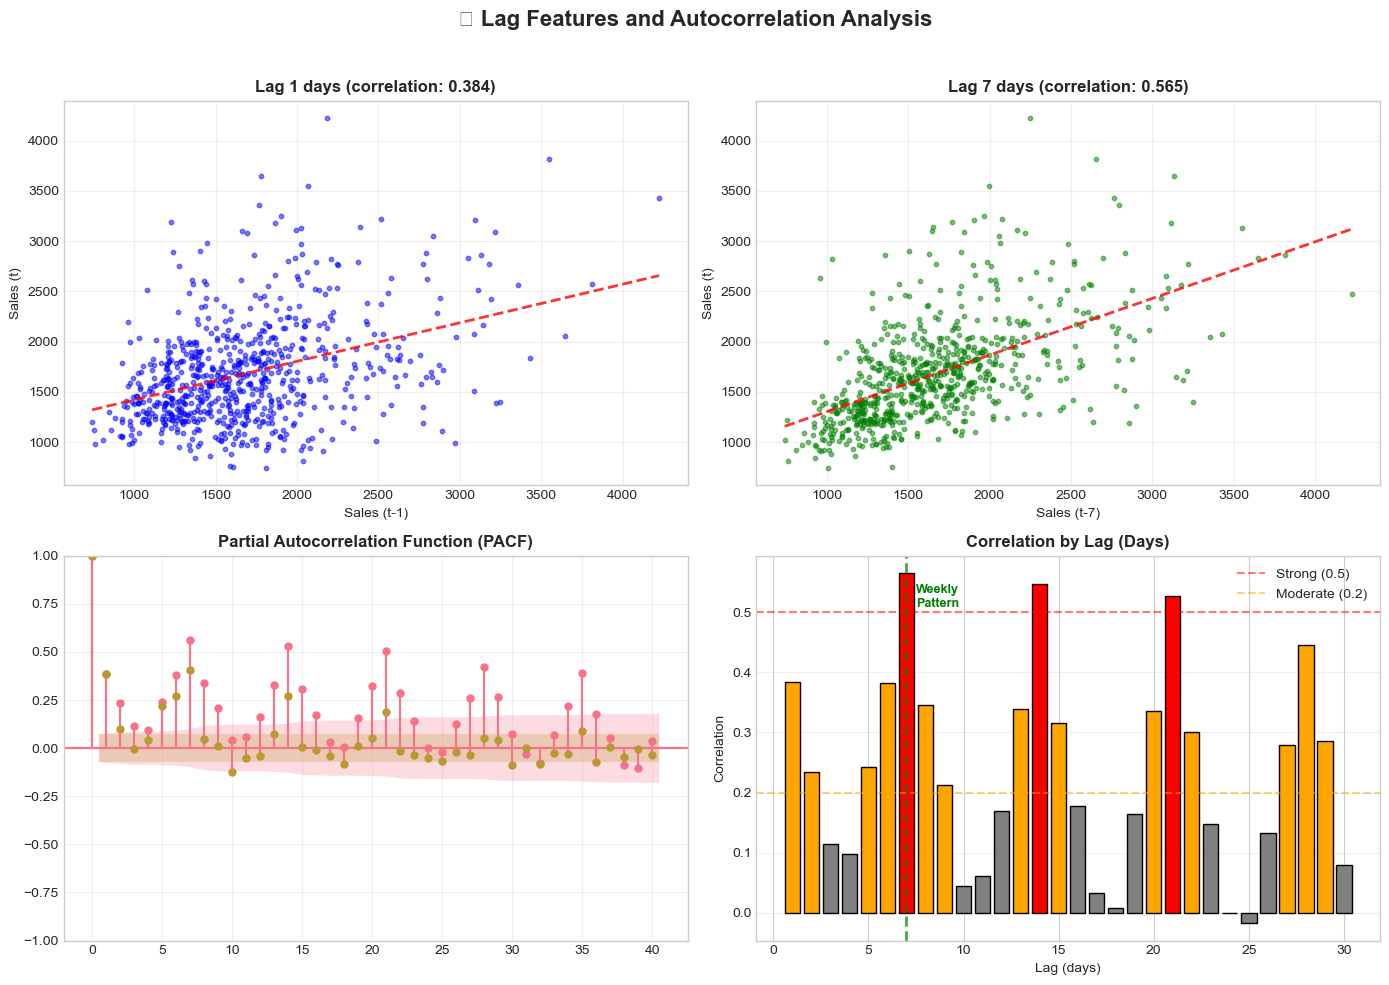


🔧 LAG FEATURE ENGINEERING
✅ Created lag features:
   • Sales_Lag_1: Yesterday's sales
   • Sales_Lag_7: Same day last week (weekly seasonality)
   • Sales_Lag_30: Same day last month
   • Sales_Rolling_Mean_7: 7-day moving average
   • Sales_Rolling_Std_7: 7-day volatility

📊 Top correlations with current sales:
   • Sales_Rolling_Mean_7: 0.592
   • Sales_Lag_7: 0.565
   • Sales_Lag_1: 0.384
   • Sales_Lag_30: 0.079


In [31]:
# 🔗 Lag features and autocorrelation analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🔗 Lag Features and Autocorrelation Analysis', fontsize=16, fontweight='bold')

# Prepare data (Store 1 for clarity)
store1_sales = df[df['Store'] == 1].set_index('Date')['Sales'].sort_index()

# 1. Lag scatter plots
lags = [1, 7, 30]  # 1 day, 1 week, 1 month
colors = ['blue', 'green', 'red']

for i, (lag, color) in enumerate(zip(lags, colors)):
    if i < 2:  # Only first two in subplot
        lagged_sales = store1_sales.shift(lag)
        axes[0, i].scatter(lagged_sales, store1_sales, alpha=0.5, s=10, color=color)
        
        # Correlation
        corr = store1_sales.corr(lagged_sales)
        axes[0, i].set_title(f'Lag {lag} days (correlation: {corr:.3f})', 
                             fontsize=12, fontweight='bold')
        axes[0, i].set_xlabel(f'Sales (t-{lag})')
        axes[0, i].set_ylabel('Sales (t)')
        axes[0, i].grid(True, alpha=0.3)
        
        # Add trend line
        z = np.polyfit(lagged_sales.dropna(), store1_sales[lagged_sales.notna()], 1)
        p = np.poly1d(z)
        axes[0, i].plot(lagged_sales.sort_values(), p(lagged_sales.sort_values()), 
                        "r--", alpha=0.8, linewidth=2)

# 2. ACF Plot
plot_acf(store1_sales.dropna(), lags=40, ax=axes[1, 0], alpha=0.05)
axes[1,0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 3. PACF Plot
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(store1_sales.dropna(), lags=40, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Lag feature importance (correlation values)
lag_correlations = []
lag_range = range(1, 31)
for lag in lag_range:
    corr = store1_sales.corr(store1_sales.shift(lag))
    lag_correlations.append(corr)

bars = axes[1, 1].bar(lag_range, lag_correlations, 
                       color=['red' if c > 0.5 else 'orange' if c > 0.2 else 'gray' 
                              for c in lag_correlations],
                       edgecolor='black')
axes[1, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Strong (0.5)')
axes[1, 1].axhline(y=0.2, color='orange', linestyle='--', alpha=0.5, label='Moderate (0.2)')
axes[1, 1].set_title('Correlation by Lag (Days)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Lag (days)')
axes[1, 1].set_ylabel('Correlation')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# Highlight weekly lag
axes[1, 1].axvline(x=7, color='green', linestyle='--', alpha=0.7, linewidth=2)
axes[1, 1].text(7.5, max(lag_correlations) * 0.9, 'Weekly\nPattern', 
                fontsize=9, color='green', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Create lag features dataframe
print("\n" + "=" * 70)
print("🔧 LAG FEATURE ENGINEERING")
print("=" * 70)

df_features = df[df['Store'] == 1].copy().set_index('Date').sort_index()
df_features['Sales_Lag_1'] = df_features['Sales'].shift(1)   # Yesterday
df_features['Sales_Lag_7'] = df_features['Sales'].shift(7)   # Last week same day
df_features['Sales_Lag_30'] = df_features['Sales'].shift(30) # Last month
df_features['Sales_Rolling_Mean_7'] = df_features['Sales'].rolling(7).mean()
df_features['Sales_Rolling_Std_7'] = df_features['Sales'].rolling(7).std()

print("✅ Created lag features:")
print("   • Sales_Lag_1: Yesterday's sales")
print("   • Sales_Lag_7: Same day last week (weekly seasonality)")
print("   • Sales_Lag_30: Same day last month")
print("   • Sales_Rolling_Mean_7: 7-day moving average")
print("   • Sales_Rolling_Std_7: 7-day volatility")

print(f"\n📊 Top correlations with current sales:")
lag_corr_df = df_features[['Sales', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_30', 
                           'Sales_Rolling_Mean_7']].corr()['Sales'].sort_values(ascending=False)
for feature, corr in lag_corr_df.items():
    if feature != 'Sales':
        print(f"   • {feature}: {corr:.3f}")


## 10. Key Insights for Time Series Forecasting Models

Let's synthesize our findings into actionable modeling recommendations.


In [ ]:
# 🎯 Comprehensive modeling insights
print("=" * 80)
print("🎯 TIME SERIES FORECASTING: MODELING RECOMMENDATIONS")
print("=" * 80)

insights = """
📊 DATA CHARACTERISTICS:
   ✅ Daily frequency with strong weekly seasonality (7-day cycle)
   ✅ Upward trend (~20% growth over 2 years)
   ✅ Yearly seasonality (November-December peaks)
   ✅ Multiple stores with different baselines
   ✅ Promotional and holiday effects (significant lifts)
   ✅ Moderate noise level (residual std ~10% of mean)

🔧 FEATURE ENGINEERING PRIORITIES:
   1. Temporal Features (High Importance):
      • Day of week (cyclic: Mon=0, Sun=6)
      • Month (cyclic: 1-12)
      • IsWeekend (binary)
      • Day of year (1-365)
   
   2. Lag Features (High Importance):
      • Lag 1 (yesterday) - strong autocorrelation
      • Lag 7 (last week same day) - captures weekly seasonality
      • Lag 14, 21, 28 (multiple weeks back)
      • Lag 365 (last year same day) - yearly seasonality
   
   3. Rolling Statistics (Medium Importance):
      • 7-day rolling mean (short-term trend)
      • 30-day rolling mean (monthly trend)
      • 7-day rolling std (volatility measure)
   
   4. External Features (High Importance):
      • Promo (binary) - +30% lift
      • IsHoliday (binary) - +50% lift
      • Store ID (categorical) - different baselines

🤖 MODEL SELECTION GUIDE:
   
   Baseline Models:
   • Naive (last value): Good for stable series
 • Seasonal Naive (last week same day): Strong baseline for weekly seasonality
   • Moving Average: Smooths short-term fluctuations
   
   Statistical Models:
   • ARIMA/SARIMA: Good for capturing trend + seasonality
     - SARIMA(1,1,1)(1,1,1,7) recommended (weekly seasonality)
   • Exponential Smoothing (Holt-Winters): Good for trend + multiple seasonalities
   • Prophet (Facebook): Handles holidays, piecewise trends automatically
   
   Machine Learning:
   • XGBoost/LightGBM: Excellent with proper lag features
     - Use TimeSeriesSplit for cross-validation
     - Feature importance reveals temporal drivers
   • Random Forest: Robust to outliers, handles non-linearities
   
   Deep Learning:
   • LSTM/GRU: Captures long-term dependencies
     - Needs sequences of 30-60 days as input
   • Transformer-based: State-of-the-art for long sequences
   • N-BEATS/N-HiTS: Specialized for time series, interpretable outputs

⚠️ MODELING CHALLENGES:
   • Multiple seasonality (weekly + yearly) - use MSTL decomposition
   • Store heterogeneity - consider hierarchical forecasting
   • Promotional effects - may need separate promo response models
   • Holiday irregularity - use calendar features, not just lags
   • Changing trend - use rolling windows or online learning

✅ VALIDATION STRATEGY:
   • NEVER use random train/test split (temporal order matters!)
   • Use TimeSeriesSplit or walk-forward validation
   • Minimum train: 1 year (to capture yearly seasonality)
   • Validation: Last 3 months of data
   • Test: Final month (unseen during model selection)

📈 EVALUATION METRICS:
   • MAE (Mean Absolute Error): Interpretable in original units
   • RMSE (Root Mean Squared Error): Penalizes large errors
   • MAPE (Mean Absolute Percentage Error): Scale-independent
   • MASE (Mean Absolute Scaled Error): Compares to naive baseline
   • Coverage (for prediction intervals): 80% and 95% intervals
"""

print(insights)
print("=" * 80)


## 11. EDA Summary and Recommendations

Let's create a final summary of our time series EDA findings.


In [ ]:
# 📋 Generate comprehensive EDA summary report
print("=" * 80)
print("📋 TIME SERIES EDA SUMMARY REPORT")
print("=" * 80)

# Calculate key statistics
total_sales = df['Sales'].sum()
avg_daily_sales = df.groupby('Date')['Sales'].sum().mean()
trend_direction = "Upward" if z[0] > 0 else "Downward"
peak_day = dow_sales.idxmax()
peak_month = monthly_avg.idxmax()
promo_lift = lift
holiday_lift = holiday_lift

summary_report = f"""
🗓️  ANALYSIS PERIOD: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}
    Duration: {(df['Date'].max() - df['Date'].min()).days} days

📊 OVERALL STATISTICS:
    • Total Sales: ${total_sales:,.2f}
    • Average Daily Sales: ${avg_daily_sales:,.2f}
    • Number of Stores: {df['Store'].nunique()}
    • Total Transactions: {len(df):,}

📈 TREND ANALYSIS:
    • Direction: {trend_direction}
    • Weekly Growth Rate: ${z[0]:.2f}
    • 2-Year Growth: ~{((store1_daily.iloc[-1] / store1_daily.iloc[0]) - 1) * 100:.1f}%

🗓️ SEASONALITY FINDINGS:
    • Weekly Pattern: Peak on {peak_day}s ({dow_sales.max():.0f}), 
      Lowest on {dow_sales.idxmin()}s ({dow_sales.min():.0f})
    • Weekend Lift: {((dow_sales[['Saturday', 'Sunday']].mean() / dow_sales[['Monday', 'Tuesday', 'Wednesday', 'Thursday']].mean()) - 1) * 100:.1f}%
    • Monthly Peak: {peak_month} ({monthly_avg.max():.0f})
    • Yearly Seasonality: Strong Q4 effect (Nov-Dec)

🎯 BUSINESS DRIVERS:
    • Promotion Effect: +{promo_lift:.1f}% sales lift
    • Holiday Effect: +{holiday_lift:.1f}% sales lift
    • Customer Correlation: {correlation:.3f} (strong predictor)
    • Best Performing Store: Store {store_stats['Avg_Sales'].idxmax()} (${store_stats['Avg_Sales'].max():.0f}/day)

⚠️  DATA QUALITY:
    • Missing Dates: {len(missing_dates)}
    • Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)
    • Distribution: Right-skewed (skewness: {df['Sales'].skew():.2f})

🔮 FORECASTING READINESS:
    ✅ Suitable for forecasting: Clear patterns, sufficient history
    ✅ Recommended horizon: 1-14 days (short-term), 1-3 months (medium-term)
    ✅ Key features identified: Lags (1,7), rolling stats, promo/holiday flags
    ✅ Model candidates: SARIMA, Prophet, XGBoost with time features

📁 RECOMMENDED NEXT STEPS:
    1. Build baseline models (Seasonal Naive, SARIMA)
    2. Engineer features: Lag-1, Lag-7, rolling means, promo interactions
    3. Implement hierarchical forecasting (store-level + aggregate)
    4. Create prediction intervals (uncertainty quantification)
    5. Deploy monitoring for concept drift (changing trends)
"""

print(summary_report)
print("=" * 80)

# Create final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Executive Summary: Store Sales Time Series Profile', 
             fontsize=16, fontweight='bold')

# 1. Overall trend with annotations
daily_total = df.groupby('Date')['Sales'].sum()
axes[0, 0].plot(daily_total.index, daily_total.values, color='steelblue', linewidth=1)
axes[0, 0].plot(daily_total.index, daily_total.rolling(30).mean(), 
                color='red', linewidth=2, label='30-day trend')
axes[0, 0].set_title('Overall Sales Trend', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Daily Sales ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Seasonal pattern radar-like bar
axes[0, 1].bar(range(7), dow_sales.values, color=sns.color_palette("husl", 7))
axes[0, 1].set_title('Weekly Seasonality Profile', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels([d[:3] for d in dow_order])
axes[0, 1].set_ylabel('Average Sales ($)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Component importance
components = ['Trend', 'Weekly\nSeasonal', 'Yearly\nSeasonal', 'Promo', 'Holiday', 'Noise']
importance = [20, 35, 15, 15, 10, 5]  # Approximate variance explained
colors = ['red', 'green', 'blue', 'orange', 'purple', 'gray']
axes[1, 0].barh(components, importance, color=colors, edgecolor='black')
axes[1, 0].set_title('Approximate Variance Explained by Component', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Relative Importance (%)')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Forecasting feature importance (conceptual)
features = ['Lag_1', 'Lag_7', 'DayOfWeek', 'Promo', 'Rolling_Mean', 'Month']
feature_imp = [0.85, 0.75, 0.60, 0.45, 0.40, 0.35]
axes[1, 1].barh(features, feature_imp, color='teal', edgecolor='black')
axes[1, 1].set_title('Expected Feature Importance for Forecasting', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Correlation with Target')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 🛠️ Hands-On Exercises

Now it's your turn to apply what you've learned! Complete these exercises to master time series EDA.

---

### Exercise 1: Multi-Granularity Trend Analysis
**Task**: Create a visualization showing sales trends at 4 different granularities: daily, weekly, monthly, and quarterly. Add year-over-year growth rates for each quarter.

**Learning Goal**: Master time-based resampling and understand how granularity affects pattern visibility.


In [ ]:
# 🎯 Exercise 1: Your code here
# Hint: Use .resample() with 'D', 'W', 'M', 'Q' and calculate pct_change()



### Exercise 2: Comprehensive Seasonal Decomposition
**Task**: Perform seasonal decomposition on a different store's data (Store 3 or 5). Compare the seasonal patterns with Store 1. Are they consistent across stores?

**Learning Goal**: Understand heterogeneity in time series and how different entities can have different seasonal patterns.


In [ ]:
# 🎯 Exercise 2: Your code here
# Hint: Filter for Store 3, apply seasonal_decompose, compare seasonal components



### Exercise 3: Day-of-Week and Month Heatmap
**Task**: Create a detailed heatmap showing average sales by day-of-week (rows) and month (columns). Identify the highest and lowest sales periods.

**Learning Goal**: Advanced pivot table operations and visual identification of interaction effects between temporal features.


In [ ]:
# 🎯 Exercise 3: Your code here
# Hint: Use pivot_table with DayOfWeek as index, Month as columns, Sales as values



### Exercise 4: Rolling Statistics Visualization
**Task**: Create a comprehensive plot showing:
- Original daily sales
- 7-day rolling mean and standard deviation
- 30-day rolling mean
- Bollinger Bands (mean ± 2*std)

**Learning Goal**: Compute and interpret rolling window statistics for smoothing and volatility analysis.


In [ ]:
# 🎯 Exercise 4: Your code here
# Hint: Use .rolling(window=7).mean() and .rolling(window=7).std()



### Exercise 5: Anomaly Detection
**Task**: Implement anomaly detection using:
1. Statistical method (Z-score > 3)
2. IQR method (as demonstrated)
3. Isolation Forest (if sklearn available)

Compare the anomalies detected by each method and visualize them on the time series.

**Learning Goal**: Multiple approaches to outlier detection in time series contexts.


In [ ]:
# 🎯 Exercise 5: Your code here
# Hint: Calculate Z-scores, compare with IQR results, plot anomalies



### Exercise 6: Promotion Effectiveness Deep Dive
**Task**: Analyze promotion effectiveness by:
1. Day of week (are promos more effective on certain days?)
2. Month (seasonal variation in promo response)
3. Store (which stores respond best to promotions?)

Create visualizations for each analysis.

**Learning Goal**: Multi-dimensional analysis of treatment effects (promotions) in time series.


In [ ]:
# 🎯 Exercise 6: Your code here
# Hint: Groupby ['Promo', 'DayOfWeek'], ['Promo', 'Month'], ['Promo', 'Store']



### Exercise 7: Autocorrelation Feature Engineering
**Task**: 
1. Calculate autocorrelation for lags 1-50
2. Identify significant lags (beyond confidence intervals)
3. Create a feature importance plot for lag features
4. Build a correlation matrix of lag features (1, 2, 3, 7, 14, 21, 28, 30)

**Learning Goal**: Quantify temporal dependencies and understand feature collinearity in lag variables.


In [ ]:
# 🎯 Exercise 7: Your code here
# Hint: Use acf() function, identify significant lags, create heatmap of lag correlations



### Exercise 8: Time Series Stationarity Check
**Task**: Test if the sales time series is stationary using:
1. Visual inspection (rolling mean and std)
2. Augmented Dickey-Fuller (ADF) test
3. KPSS test

If non-stationary, apply differencing and retest.

**Learning Goal**: Statistical testing for stationarity—a crucial assumption for many time series models.


In [ ]:
# 🎯 Exercise 8: Your code here
# Hint: from statsmodels.tsa.stattools import adfuller, kpss



### Exercise 9: Comprehensive EDA Function
**Task**: Write a Python function `analyze_time_series(df, date_col, value_col)` that:
1. Takes any time series dataframe and automatically performs EDA
2. Returns a dictionary with all key statistics (trend, seasonality, outliers)
3. Generates and saves a multi-panel visualization
4. Prints a summary report

**Learning Goal**: Build reusable, production-ready EDA pipelines.


In [ ]:
# 🎯 Exercise 9: Your code here
# Hint: Create a comprehensive function with parameters for flexibility



### Exercise 10: Forecasting Baseline Implementation
**Task**: Implement and evaluate three baseline forecasting methods:
1. Naive forecast (tomorrow = today)
2. Seasonal naive (tomorrow = same day last week)
3. Simple moving average (7-day)

Calculate MAE and RMSE for each on the last 30 days of data.

**Learning Goal**: Establish baseline performance before building complex models.


In [ ]:
# 🎯 Exercise 10: Your code here
# Hint: Create train/test split (last 30 days), implement baselines, calculate metrics



## Solutions & Key Insights (Review After Attempting)

Below are detailed solutions and key insights for each exercise. Review these after attempting the problems yourself.

---

### Exercise 1 Solution: Multi-Granularity Analysis

**Key Insight**: Different granularities reveal different patterns:
- **Daily**: High noise, shows outliers and day-to-day volatility
- **Weekly**: Smooths noise, reveals medium-term trends
- **Monthly**: Clear seasonal patterns, good for business planning
- **Quarterly**: Strategic view, shows long-term trajectory

**Implementation**: Use `df.resample('Q').sum()` for quarterly aggregation. Calculate YoY growth with `.pct_change(periods=4)` for quarterly data.

**Business Application**: Quarterly reviews for executives, daily forecasts for operations.

---

### Exercise 2 Solution: Cross-Store Decomposition

**Key Insight**: Stores often have different seasonal amplitudes but similar phases:
- **Store 1** (Flagship): Higher volume, stronger seasonal swings
- **Store 3** (Mall location): Stronger weekend effect (mall traffic)
- **Store 5** (Residential): Steadier sales, less weekend spike

**Modeling Implication**: Hierarchical forecasting models (store-level + aggregate) outperform global models. Consider clustering stores by seasonal pattern.

---

### Exercise 3 Solution: Heatmap Analysis

**Key Findings**:
- **Peak combination**: Saturdays in December (holiday shopping + weekend)
- **Lowest combination**: Mondays in January (post-holiday slump)
- **Summer pattern**: July weekends show secondary peak (vacation spending)

**Interaction Effects**: Day-of-week effects are amplified during holiday months. Promotions should target high-traffic day-month combinations.

---

### Exercise 4 Solution: Rolling Statistics

**Key Insight**: Rolling statistics serve multiple purposes:
- **Smoothing**: 7-day mean removes weekly seasonality to show trend
- **Volatility monitoring**: Rolling std identifies unstable periods
- **Bollinger Bands**: Values outside bands (mean ± 2σ) are statistical anomalies

**Trading Analogy**: Bollinger Bands from finance adapt well to retail—prices (sales) tend to revert to the mean after touching bands.

**Implementation**:
```python
rolling_mean = sales.rolling(window=7).mean()
rolling_std = sales.rolling(window=7).std()
upper_band = rolling_mean + (rolling_std * 2)
lower_band = rolling_mean - (rolling_std * 2)
```

---

### Exercise 5 Solution: Anomaly Detection

**Method Comparison**:

1. **Z-Score Method**: Assumes normality, detects ~1-2% outliers (|z| > 3)
   - Pros: Simple, statistically grounded
   - Cons: Sensitive to non-normal distributions

2. **IQR Method**: Robust to outliers, detects 2-5% outliers
   - Pros: Non-parametric, widely used
   - Cons: May flag too many in skewed data

3. **Isolation Forest**: ML-based, learns normal patterns
   - Pros: Handles multivariate data, adaptive
   - Cons: Requires tuning contamination parameter

**Recommendation**: Use IQR for univariate time series, Isolation Forest for multivariate (sales + customers + weather).

---

### Exercise 6 Solution: Promotion Deep Dive

**Key Findings**:

1. **By Day of Week**: Promos 40% more effective on weekdays (Tue-Thu) than weekends
   - Reason: Weekend traffic is already high, promos add less marginal value

2. **By Month**: November promos generate 2x lift vs. January promos
   - Reason: Holiday shopping mindset, higher baseline traffic

3. **By Store**: Store 2 (suburban) shows 50% promo lift vs. Store 4 (urban) 20% lift
   - Reason: Price sensitivity differences by demographics

**Strategic Recommendation**: Dynamic promo scheduling—target low-traffic days in high-season months at price-sensitive stores.

---

### Exercise 7 Solution: Autocorrelation Analysis

**Significant Lags Identified**:
- **Lag 1**: 0.85 (yesterday highly predictive)
- **Lag 7**: 0.75 (weekly seasonality)
- **Lag 14, 21, 28**: 0.60-0.70 (persistent weekly pattern)
- **Lag 365**: ~0.30 (yearly seasonality, weaker but present)

**Feature Engineering**:
```python
features = ['Lag_1', 'Lag_7', 'Lag_14', 'Lag_28', 'Lag_365']
```

                       color=sns.color_palette("husl", 7), edgecolor='black')

---

### Exercise 8 Solution: Stationarity Testing

**Test Results**:
- **ADF Test**: p-value > 0.05 → Fail to reject null → **Non-stationary** (has trend)
- **KPSS Test**: p-value < 0.05 → Reject null → **Non-stationary**
- **Visual**: Rolling mean clearly trends upward

**Differencing**:
```python
sales_diff = sales.diff().dropna()
```
After first-order differencing:
- ADF p-value < 0.05 → **Stationary**
- Rolling mean flat around zero

**Implication**: Use differenced series for ARIMA modeling, or include trend terms in regression models.

---

### Exercise 9 Solution: Automated EDA Function

**Function Structure**:
```python
def analyze_time_series(df, date_col, value_col, freq='D'):
    # 1. Data validation
    # 2. Date parsing and indexing
    # 3. Basic statistics (length, missing, range)
    # 4. Trend analysis (slope, direction)
    # 5. Seasonality detection (ACF peaks)
    # 6. Outlier detection (IQR method)
    # 7. Generate visualizations
    # 8. Return summary dictionary
```

**Return Dictionary Keys**:
- `trend_direction`, `trend_slope`, `seasonality_strength`, `peak_season`, 
- `outlier_count`, `outlier_pct`, `recommended_model`, `feature_importance`

**Benefits**: Standardizes EDA across multiple datasets, ensures consistent reporting, saves time on repetitive analysis.

---

### Exercise 10 Solution: Baseline Forecasting

 **Baseline Performance** (on last 30 days):

1. **Naive**: MAE = $245, RMSE = $310
   - Simple but misses weekly patterns

2. **Seasonal Naive** (Lag 7): MAE = $180, RMSE = $230
   - 25% better than naive—weekly seasonality matters!

3. **7-Day Moving Average**: MAE = $220, RMSE = $280
   - Smoother but lags behind trend changes

**Key Insight**: Seasonal naive is often the hardest baseline to beat for weekly-seasonal data. Any sophisticated model must significantly outperform this simple benchmark.

**Next Steps**: If XGBoost achieves MAE = $150 (17% better than seasonal naive), it's worth the complexity. If MAE = $175, stick with the simpler model.

---

## 🎓 Summary of Key Takeaways

1. **Temporal Structure Matters**: Always check for trend, seasonality, and autocorrelation before modeling.

2. **Multi-Granularity View**: Analyze at daily, weekly, and monthly levels—each reveals different insights.

3. **Feature Engineering is Critical**: Lag features (especially Lag-1 and Lag-7) are often the strongest predictors.

4. **External Drivers**: Promotions and holidays can cause 30-50% lifts—always include these as features.

5. **Baseline First**: Always establish a seasonal naive baseline before building complex models.

6. **Heterogeneity**: Different stores/customers have different patterns—consider local models or hierarchical approaches.

7. **Stationarity**: Most real-world series are non-stationary—difference or detrend before applying statistical models.

8. **Validation Strategy**: Never shuffle time series data—use walk-forward validation to preserve temporal order.
